Missing values in Stock Details :
      StockCode  Description
0         False        False
1         False        False
2         False        False
3         False        False
4         False        False
...         ...          ...
1698      False        False
1699      False        False
1700      False        False
1701      False        False
1702      False        False

[1703 rows x 2 columns]
Missing values in Sales :
      InvoiceNo  StockCode  Description  Quantity  InvoiceDate  UnitPrice  \
0         False      False        False     False        False      False   
1         False      False        False     False        False      False   
2         False      False        False     False        False      False   
3         False      False        False     False        False      False   
4         False      False        False     False        False      False   
...         ...        ...          ...       ...          ...        ...   
9490      False      False  

CustomerID  InvoiceNo
12426       554985        8.600000
12427       536861        7.900000
            570452        7.600000
            577135       56.666667
            C539866      -3.000000
                           ...    
13816       C576229      -3.000000
13817       539946        7.000000
            575713        9.866667
14335       565430        8.095238
            578273        1.857143
Name: Quantity, Length: 603, dtype: float64

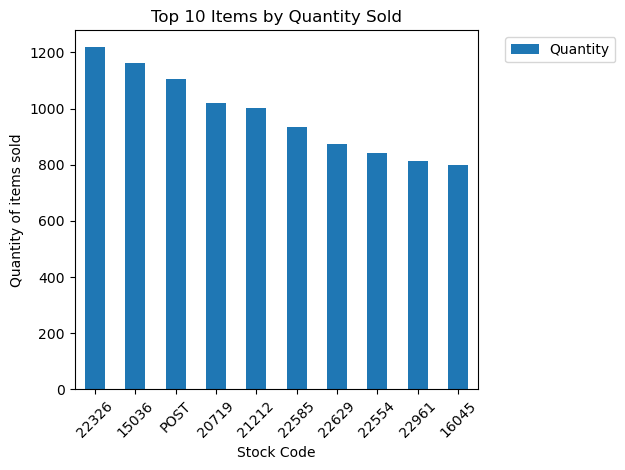

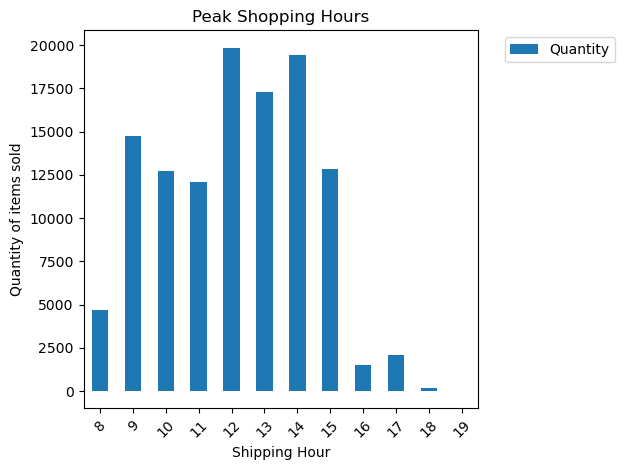

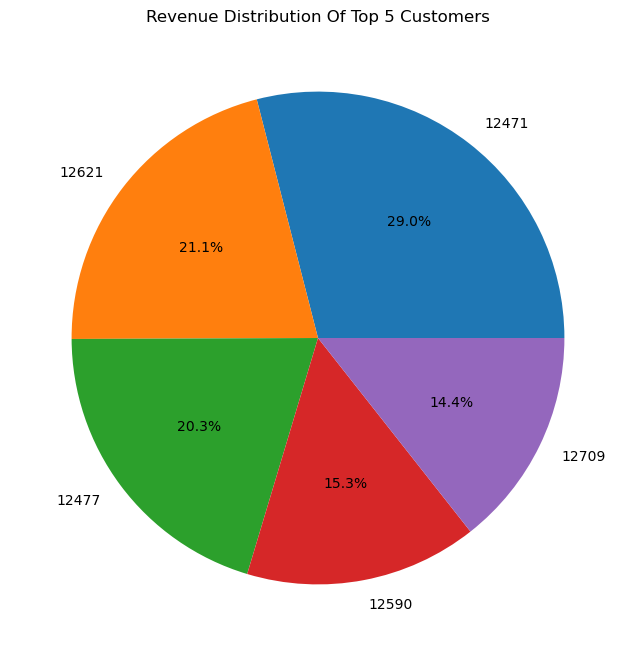

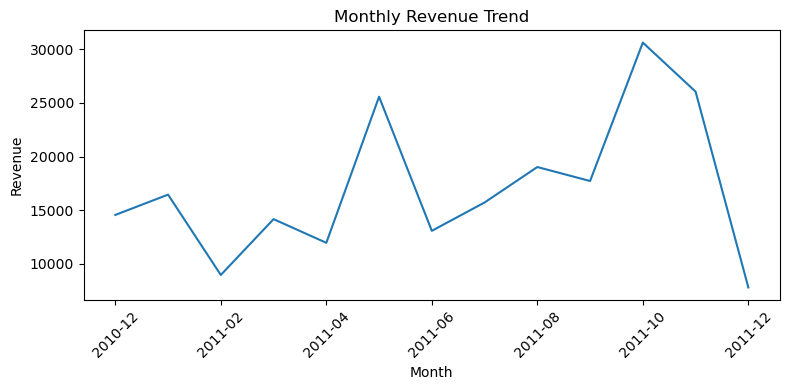

/var/folders/lw/gbxc6dn53kbc5980g_f66jfm0000gn/T/ipykernel_27945/181820822.py:136: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


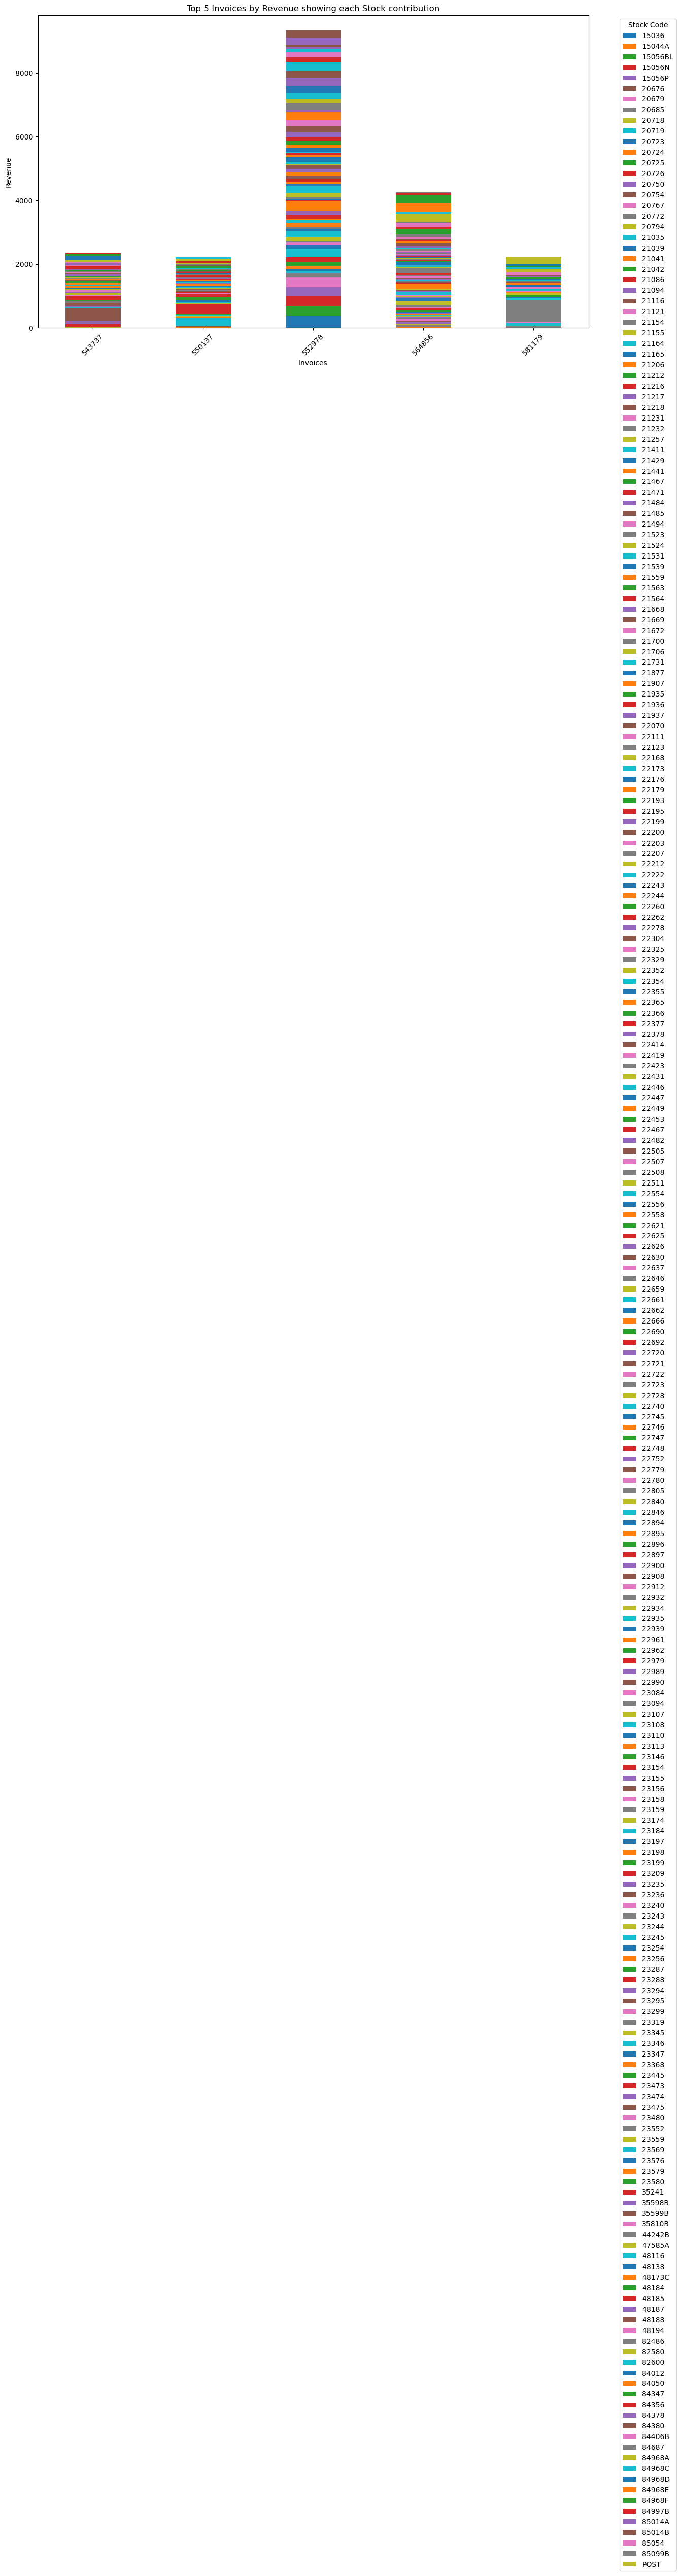

Top revenue item is (POST): POSTAGE
 The average order value per invoice is (InvoiceNo
536527     2.96
536840     3.95
536861     4.92
536967     9.98
536983     5.18
           ... 
C580313    2.42
C580714    3.10
C580740    1.25
C580989    1.65
C581409    5.02
Name: UnitPrice, Length: 603, dtype: float64)
 The customer 12471 has maximum transactions:531
The products in Sales that are not in Stock details are: Empty DataFrame
Columns: [InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country, Date, Month, HourOfTransaction, TotalPrice, Revenue, InvoiceMonthYear]
Index: []
The number of products in sales not matching in stock details is :0


In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

#Create data frames for the data sets by reading the csv files
StockDetails_df= pd.read_csv('/Users/ravvarma/Documents/Personal/AI & ML IITM /Week-8-Graded_Project/StockDetails.csv')
Sales_df= pd.read_csv('/Users/ravvarma/Documents/Personal/AI & ML IITM /Week-8-Graded_Project/Sales.csv')

#A.Check for missing values, data types, and duplicates in both datasets

# Check for missing values and printing them 
print(f"Missing values in Stock Details :\n{StockDetails_df.isna()}")
print(f"Missing values in Sales :\n{Sales_df.isna()}")

# Check for data types of the data in both data sets'
print(f"The datatype of data in StockDetails is :\n{StockDetails_df.dtypes}")
print(f"The datatype of data in Sales is :\n{Sales_df.dtypes}")

# Check for duplicates in the StockDetails data sets and print them'
print(f"Duplicates in StockDetails data set are :\n{StockDetails_df[StockDetails_df.duplicated]}")

# Check for duplicates in the Sales data sets and print them'
print(f"Duplicates in Sales data set are :\n{Sales_df[Sales_df.duplicated]}")

#B.Convert InvoiceDate into datetime, and extract InvoiceDate, Month and Hour of transaction
# Convert into datetime 
Sales_df['InvoiceDate'] = pd.to_datetime(Sales_df['InvoiceDate'],format='%d-%m-%Y %H:%M')

# Extract date
Sales_df['Date'] = Sales_df['InvoiceDate'].dt.date
# Extract month 
Sales_df['Month'] = Sales_df['InvoiceDate'].dt.month
# Extract time 
Sales_df['HourOfTransaction'] = Sales_df['InvoiceDate'].dt.hour
print (f"Invoice Date of transaction:\n{Sales_df['Date']}")
print (f"Month of transaction:\n{Sales_df['Month']}")
print (f"Hour of transaction:\n{Sales_df['HourOfTransaction']}")
 
# Add a new column TotalPrice = Quantity × UnitPrice to the data frame
Sales_df['TotalPrice'] = Sales_df['Quantity']* Sales_df['UnitPrice']

# Identify the top 3 bestselling items by quantity sold.
# Group by stockcode on the sum of quantity sold and use nlargest() to pick the top 3 
Top3_df = Sales_df.groupby('StockCode')['Quantity'].sum().nlargest(3)
print(f"Top 3 stocks by quantity sold :\n{Top3_df}")

# Find out how many unique customers made purchases and the average quantity per invoice.
UniqueCustomerMakingPurchase = Sales_df['CustomerID'].nunique()
print(f"Number of Unique Customers making purchase is:{UniqueCustomerMakingPurchase}")

AvgPurchase_df = Sales_df.groupby(['CustomerID', 'InvoiceNo'])['Quantity'].mean()
print(f"Average quantity per invoice:\n")
display(AvgPurchase_df)


#C.Visualization (5 Tasks)
#11. Plot a bar chart of top 10 items by quantity sold.
Top10_df = Sales_df.groupby('StockCode')['Quantity'].sum().nlargest(10)
Top10_df.plot(kind='bar', x='StockCode', y='QuantitySold', title='Top 10 Items by Quantity Sold')
plt.xlabel("Stock Code")
plt.ylabel("Quantity of items sold")
plt.xticks(rotation=45)
plt.legend( bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#12. Plot total sales per hour of the day to understand peak shopping hours.
#Convert InvoiceDate to date time format
Sales_df['InvoiceDate'] = pd.to_datetime(Sales_df['InvoiceDate'],format='%d-%m-%Y %H:%M')
SalesPerHour_df = Sales_df.groupby(Sales_df['InvoiceDate'].dt.hour)['Quantity'].sum()
SalesPerHour_df.plot(kind='bar', x='Hour', y='QuantitySold', title='Peak Shopping Hours')
plt.xlabel("Shipping Hour")
plt.ylabel("Quantity of items sold")
plt.xticks(rotation=45)
plt.legend( bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#13. Create a pie chart showing revenue distribution among top 5 customers
#Calculate revenue
Sales_df['Revenue'] = Sales_df['Quantity']* Sales_df['UnitPrice']
#Fetch top 5 customers by revenue
Top5_df = Sales_df.groupby('CustomerID')['Revenue'].sum().nlargest(5)
#Create pie chart
Top5_df.plot.pie(y='Revenue',autopct='%1.1f%%', figsize=(8, 8))
plt.title('Revenue Distribution Of Top 5 Customers')
#remove the ylabel from left side of pie chart
plt.ylabel('')
plt.show()

#14. Visualize the monthly revenue trend using a line chart.
#Convert InvoiceDate to date time format and extract month and year
Sales_df['InvoiceDate'] = pd.to_datetime(Sales_df['InvoiceDate'],format='%d-%m-%Y %H:%M')
Sales_df['InvoiceMonthYear'] = Sales_df['InvoiceDate'].dt.strftime('%Y-%m')

#Calculate revenue and group the revenue by month and year
Sales_df['Revenue'] = Sales_df['Quantity']* Sales_df['UnitPrice']
MonthlyRevenue_df = Sales_df.groupby('InvoiceMonthYear')['Revenue'].sum()
MonthlyRevenue_df = MonthlyRevenue_df.sort_index()

#Plot the revenue by month and year
plt.figure(figsize=(8, 4))
MonthlyRevenue_df.plot(kind='line')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45) 
plt.tight_layout()  
plt.show()

#15.Create a stacked bar chart of top 5 invoices by revenue, showing contribution from each item.
# Calculate total revenue per item
Sales_df['Revenue'] = round(Sales_df['Quantity']* Sales_df['UnitPrice'],2)

# Find top 5 invoices by revenue
Top5Invoices_df = Sales_df.groupby('InvoiceNo')['Revenue'].sum().nlargest(5).index.tolist()

# Pick data for top 5 invoices separately for creating a pivot
TopInvoices = Sales_df[Sales_df['InvoiceNo'].isin(Top5Invoices_df)]

# Create a pivot of these top 5 invoices
pivot_data = TopInvoices.pivot_table(
    index='InvoiceNo', 
    columns='StockCode', 
    values='Revenue',
    aggfunc='sum',
    fill_value=0
)

#Using the pivot data, create the stacked bar graph and adjust the formating of plot
pivot_data.plot(kind='bar', stacked=True, figsize=(14,8))
plt.title('Top 5 Invoices by Revenue showing each Stock contribution')
plt.xlabel('Invoices')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend(title='Stock Code', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# D. Business Insights (4 Tasks)
# 16.Identify which product generates the highest total revenue.

# Calculate total revenue per item
Sales_df['Revenue'] = round(Sales_df['Quantity']* Sales_df['UnitPrice'],2)

# Find the item which produces maximum revenue
TopRevenueItem_df = Sales_df.groupby('StockCode')['Revenue'].sum().nlargest(1)

# Get the stockcode and description of the top revenue item 
TopStockCode = TopRevenueItem_df.index[0]
StockDescription = Sales_df[Sales_df['StockCode'] == TopStockCode]['Description'].iloc[0]

print(f"Top revenue item is ({TopStockCode}): {StockDescription}")

# 17.Determine average order value per invoice.

# Calculate the average order value per invoice
AvgOrderValue = round(Sales_df.groupby('InvoiceNo')['UnitPrice'].mean(),2)
print(f" The average order value per invoice is ({AvgOrderValue})")

# 18.Find the customer with the highest number of transactions.
HighestTransactions = Sales_df.groupby('CustomerID')['InvoiceNo'].count().nlargest(1)
print(f" The customer {HighestTransactions.index[0]} has maximum transactions:{HighestTransactions.values[0]}")

# 19.Check how many products in the sales data do not have a matching entry in the stockDetails file.
Products_not_in_StockDetails = Sales_df[~Sales_df['StockCode'].isin(StockDetails_df['StockCode'])]
print(f"The products in Sales that are not in Stock details are: {Products_not_in_StockDetails}")
unmatched_count = len(Products_not_in_StockDetails)
print(f"The number of products in sales not matching in stock details is :{unmatched_count}")
